In [1]:
%load_ext tensorboard

In [77]:
from service.exportservice.ExportService import ExportService
from service.datasetservice.DatasetService import DatasetService
import pandas as pd

dataset_service = DatasetService()
export_service = ExportService(database="project_2_windows", collection="centralized")

x_train_all = dataset_service.load_training_features(which=5).to_numpy()
x_test_all = dataset_service.load_testing_features(which=5).to_numpy()
y_train_all = dataset_service.load_training_labels(which=5).to_numpy().ravel()
y_test_all = dataset_service.load_testing_labels(which=5).to_numpy().ravel()

# x_train_all = pd.concat(x_train_all).to_numpy()
# y_train_all = pd.concat(y_train_all).to_numpy()
# 
# x_test_all = pd.concat(x_test_all).to_numpy()
# y_test_all = pd.concat(y_test_all).to_numpy()

In [78]:
run_info = {
        "model": "DNN",
        "centralized_scoring": {},
        "individual_scoring": [],
    }

In [89]:
from keras.src.optimizers import SGD
import keras
from keras import layers
import tensorflow as tf
from scikeras.wrappers import KerasClassifier

def _build_model(number_of_features: int) -> keras.Sequential:
    # Define the model
    # For the non-window approach use a simpler model
    if number_of_features == 2:
        _model = keras.Sequential()
        _model.add(layers.Dense(16, input_dim=number_of_features, activation="relu"))
        _model.add(layers.Dense(8, activation="relu"))
        _model.add(layers.Dense(4, activation="relu"))
        # Output layer with 1 neuron, sigmoid activation for binary classification
        _model.add(layers.Dense(1, activation="sigmoid"))
    else:
        # TODO Test different architectures
        _model = keras.Sequential()
        _model.add(layers.Dense(512, input_dim=number_of_features, activation="relu"))
        _model.add(layers.Dense(256, activation="relu"))
        _model.add(layers.Dense(128, activation="relu"))
        _model.add(layers.Dense(64, activation="relu"))
        _model.add(layers.Dense(54, activation="relu"))
        _model.add(layers.Dense(50, activation="relu"))
        # Output layer with 1 neuron, sigmoid activation for binary classification
        _model.add(layers.Dense(1, activation="sigmoid"))

    return _model

early_stopping_callback = keras.callbacks.EarlyStopping(patience=5)

model = KerasClassifier(
            model=_build_model(number_of_features=120),
            epochs=500,
            batch_size=32,
            verbose=1,
            validation_split=0.2,
            random_state=42,
            shuffle=True,
            callbacks=[early_stopping_callback],
            loss="binary_crossentropy",
            optimizer="adam",
            metrics=[tf.keras.metrics.F1Score(name="f1_score", average="weighted")],
        )

/home/cedric/miniconda3/envs/project_2_wsl/lib/python3.11/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [90]:
import os
import random
import numpy as np
import tensorflow as tf

def set_seed(seed):
    np.random.seed(seed)
    tf.random.set_seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    random.seed(seed)

# Call the function with your desired seed
set_seed(42)

model.fit(x_train_all, y_train_all)

Epoch 1/500
58/58 ━━━━━━━━━━━━━━━━━━━━ 4s 36ms/step - f1_score: 0.4929 - loss: 0.6728 - val_f1_score: 0.5305 - val_loss: 0.5307
Epoch 2/500
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - f1_score: 0.4929 - loss: 0.5185 - val_f1_score: 0.5305 - val_loss: 0.4830
Epoch 3/500
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - f1_score: 0.4929 - loss: 0.4584 - val_f1_score: 0.5305 - val_loss: 0.4498
Epoch 4/500
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - f1_score: 0.4945 - loss: 0.4418 - val_f1_score: 0.5419 - val_loss: 0.3926
Epoch 5/500
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - f1_score: 0.4952 - loss: 0.4135 - val_f1_score: 0.5419 - val_loss: 0.4709
Epoch 6/500
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - f1_score: 0.4985 - loss: 0.4071 - val_f1_score: 0.5473 - val_loss: 0.3929
Epoch 7/500
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - f1_score: 0.5020 - loss: 0.3749 - val_f1_score: 0.5473 - val_loss: 0.4772
Epoch 8/500
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - f1_score: 0.5021 - loss: 0.3996 - val_f1_score: 0.5473 - 

KerasClassifier(
	model=<Sequential name=sequential_21, built=True>
	build_fn=None
	warm_start=False
	random_state=42
	optimizer=adam
	loss=binary_crossentropy
	metrics=[<F1Score name=f1_score>]
	batch_size=32
	validation_batch_size=None
	verbose=1
	callbacks=[<keras.src.callbacks.early_stopping.EarlyStopping object at 0x7efcc7d50250>]
	validation_split=0.2
	shuffle=True
	run_eagerly=False
	epochs=500
	class_weight=None
)

In [91]:
from sklearn.metrics import classification_report, accuracy_score, recall_score, precision_score, f1_score

y_pred = model.predict(x_test_all)

acc = accuracy_score(y_pred, y_test_all)
rec = recall_score(y_pred, y_test_all)
prec = precision_score(y_pred, y_test_all)
f1 = f1_score(y_pred, y_test_all)

print(f"Accuracy: {acc}")
print(f"Recall: {rec}")
print(f"Precision: {prec}")
print(f"F1: {f1}")

18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
Accuracy: 0.8181818181818182
Recall: 0.8807339449541285
Precision: 0.5133689839572193
F1: 0.6486486486486487


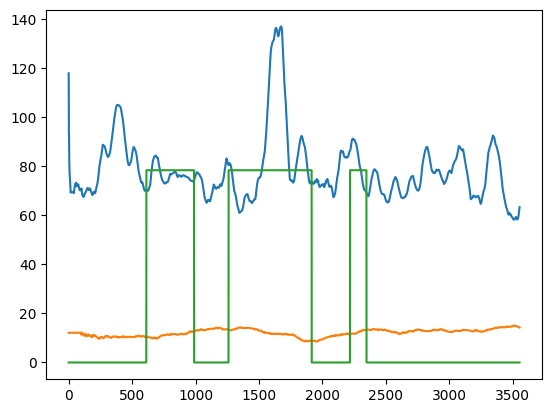

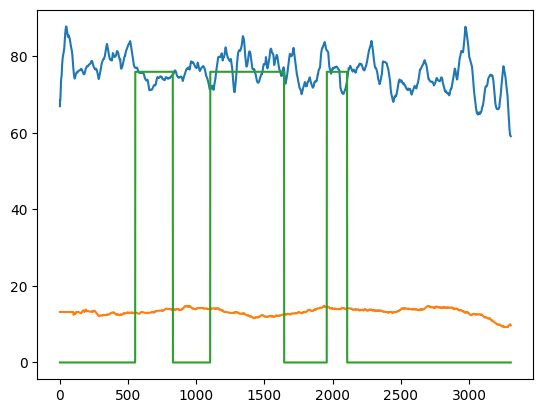

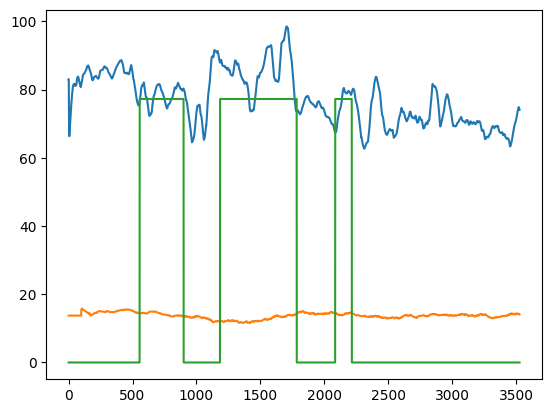

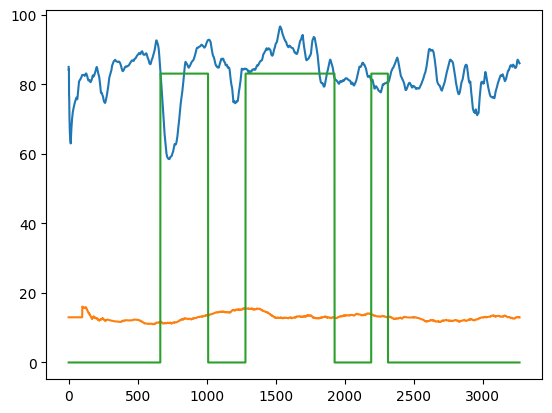

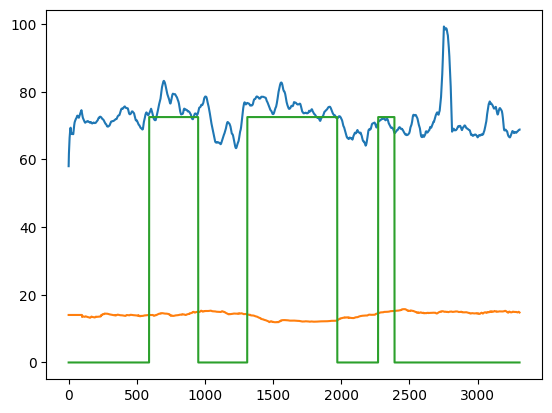

In [42]:
import matplotlib.pyplot as plt
import numpy as np

for p in (2,3,4,5,6):
    fig, ax = plt.subplots()
    hr = df[df.Participant == p].HR
    lbl = df[df.Participant == p].Label
    respr = df[df.Participant == p].respr
    
    ax.plot(list(range(len(hr))), hr)
    ax.plot(list(range(len(respr))), respr)
    ax.plot(list(range(len(hr))), lbl*np.mean(hr))
# plt.yscale('log')

(array([  105.,  5950., 34825., 41580., 25935.,  4760.,   735.,   315.,
          350.,  1260.]),
 array([58.   , 62.128, 66.256, 70.384, 74.512, 78.64 , 82.768, 86.896,
        91.024, 95.152, 99.28 ]),
 <BarContainer object of 10 artists>)

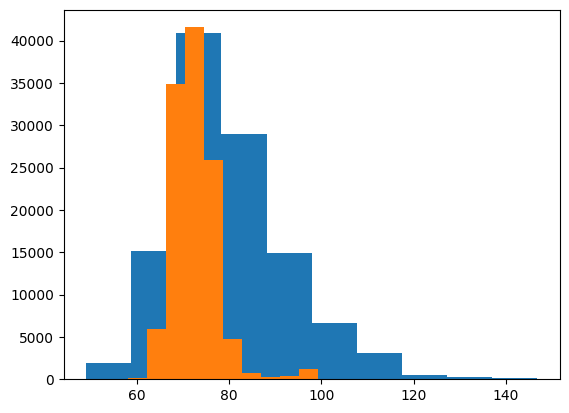

In [47]:
plt.hist(df.HR)
plt.hist(np.repeat(df[df.Participant == 6].HR, 35))

/var/folders/ng/n1v_1pr17m73rptx7l3q3hz40000gr/T/ipykernel_53287/2557845004.py:2: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  axs[0].hist(df[df.Participant == 6][df.Label == 0].HR)
/var/folders/ng/n1v_1pr17m73rptx7l3q3hz40000gr/T/ipykernel_53287/2557845004.py:4: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  axs[1].hist(df[df.Participant == 6][df.Label == 1].HR)


(60.0, 100.0)

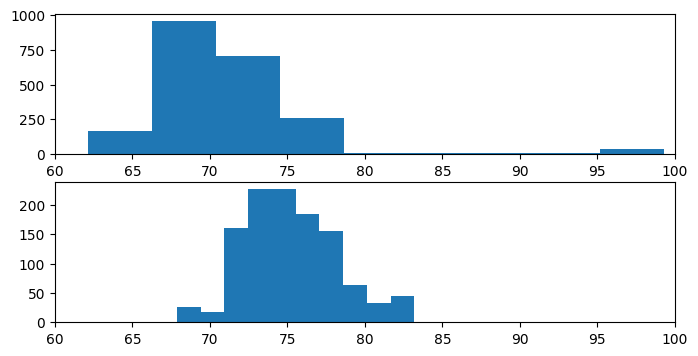

In [59]:
fig, axs = plt.subplots(2, figsize=(8, 4))
axs[0].hist(df[df.Participant == 6][df.Label == 0].HR)
axs[0].set_xlim(60,100)
axs[1].hist(df[df.Participant == 6][df.Label == 1].HR)
axs[1].set_xlim(60,100)

/var/folders/ng/n1v_1pr17m73rptx7l3q3hz40000gr/T/ipykernel_53287/196687524.py:2: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  axs[0].hist(df[df.Participant == 6][df.Label == 0].respr)
/var/folders/ng/n1v_1pr17m73rptx7l3q3hz40000gr/T/ipykernel_53287/196687524.py:4: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  axs[1].hist(df[df.Participant == 6][df.Label == 1].respr)


(10.0, 16.0)

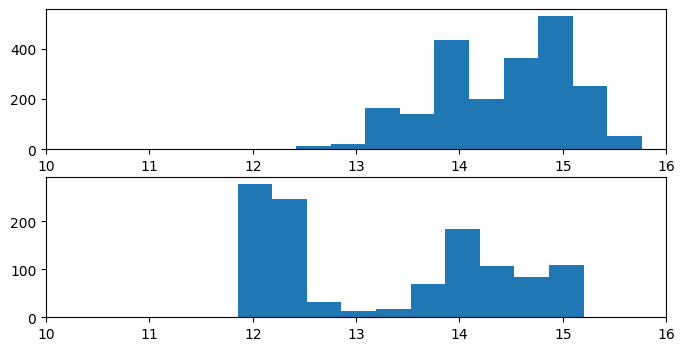

In [62]:
fig, axs = plt.subplots(2, figsize=(8, 4))
axs[0].hist(df[df.Participant == 6][df.Label == 0].respr)
axs[0].set_xlim(10,16)
axs[1].hist(df[df.Participant == 6][df.Label == 1].respr)
axs[1].set_xlim(10,16)

(10.0, 16.0)

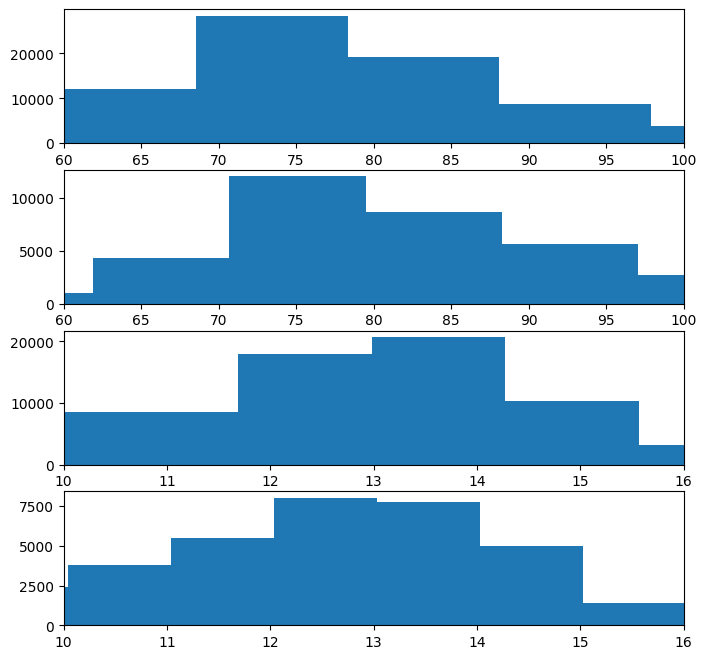

In [64]:
fig, axs = plt.subplots(4, figsize=(8, 8))

axs[0].hist(df[df.Label == 0].HR)
axs[0].set_xlim(60,100)
axs[1].hist(df[df.Label == 1].HR)
axs[1].set_xlim(60,100)

axs[2].hist(df[df.Label == 0].respr)
axs[2].set_xlim(10,16)
axs[3].hist(df[df.Label == 1].respr)
axs[3].set_xlim(10,16)

<Axes: ylabel='Label'>

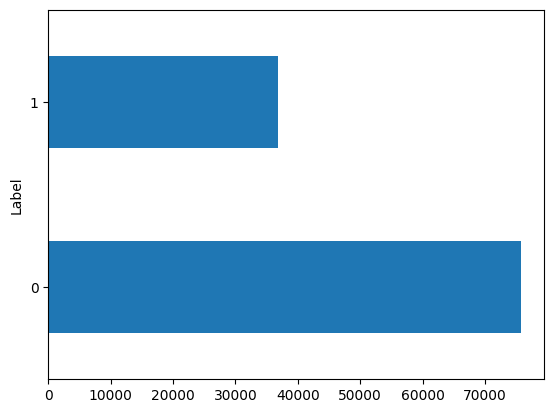

In [4]:
dataset["Label"].value_counts().plot(kind="barh")

In [5]:
dataset = dataset_service.remove_nan(dataset=dataset)
dataset.describe()

,Participant,HR,respr,Time(sec),Label
count,112472.000000,112472.000000,112472.000000,1.124720e+05,112472.000000
mean,18.475923,80.216177,12.465400,1.645692e+09,0.327326
std,9.871188,12.732206,2.030968,8.179379e+05,0.469239
min,2.000000,49.000000,5.204728,1.644228e+09,0.000000
25%,10.000000,71.330000,11.191836,1.644846e+09,0.000000
50%,18.000000,77.890000,12.743508,1.645461e+09,0.000000
75%,27.000000,87.020000,13.877583,1.646648e+09,1.000000
max,35.000000,146.780000,18.163532,1.646842e+09,1.000000


In [28]:
x, y, labels = dataset_service.get_features_and_labels(dataset=dataset)

In [32]:
from sklearn.model_selection import train_test_split

train_x, test_x, train_y, test_y = train_test_split(x, y, test_size=0.2, shuffle=True, random_state=42, stratify=y)

In [8]:
from imblearn.combine import SMOTEENN
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
resampler = SMOTEENN(random_state=42)

In [22]:
import keras
from keras import layers

def create_model():
    model_ = keras.Sequential()
    model_.add(layers.Dense(16, input_dim=2, activation='relu'))
    model_.add(layers.Dense(8, activation="relu"))
    model_.add(layers.Dense(4, activation="relu"))
    # Output layer with 1 neuron, sigmoid activation for binary classification
    model_.add(layers.Dense(1, activation="sigmoid"))
    
    # Compile the model
    model_.compile(loss="binary_crossentropy", optimizer="adam", metrics=["accuracy"])

    return model_

In [23]:
from scikeras.wrappers import KerasRegressor
from imblearn.pipeline import Pipeline
import tensorflow as tf
import datetime

tf.random.set_seed(42)

early_stopping_callback = keras.callbacks.EarlyStopping(monitor='loss', patience=9)

log_dir = "../logs/fit/" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
tensorboard_callback = tf.keras.callbacks.TensorBoard(log_dir=log_dir, histogram_freq=1)

model = KerasRegressor(model=create_model, epochs=500, batch_size=32, verbose=1, validation_split=0.2, callbacks=[early_stopping_callback, tensorboard_callback])
pipeline = Pipeline([("scaler", scaler), ("resampler", resampler), ("model", model)])




In [24]:
! rm -rf ../logs/
pipeline.fit(train_x, train_y)

Epoch 1/500
1580/1580 [==============================] - 11s 7ms/step - loss: 0.6162 - accuracy: 0.6497 - val_loss: 0.7856 - val_accuracy: 0.5404
Epoch 2/500
1580/1580 [==============================] - 10s 6ms/step - loss: 0.5852 - accuracy: 0.6870 - val_loss: 0.7782 - val_accuracy: 0.5506
Epoch 3/500
1580/1580 [==============================] - 10s 6ms/step - loss: 0.5702 - accuracy: 0.7020 - val_loss: 0.7665 - val_accuracy: 0.5111
Epoch 4/500
1580/1580 [==============================] - 10s 6ms/step - loss: 0.5582 - accuracy: 0.7097 - val_loss: 0.7276 - val_accuracy: 0.5450
Epoch 5/500
1580/1580 [==============================] - 10s 6ms/step - loss: 0.5520 - accuracy: 0.7182 - val_loss: 0.7732 - val_accuracy: 0.5223
Epoch 6/500
1580/1580 [==============================] - 10s 6ms/step - loss: 0.5465 - accuracy: 0.7220 - val_loss: 0.8815 - val_accuracy: 0.4505
Epoch 7/500
1580/1580 [==============================] - 10s 6ms/step - loss: 0.5425 - accuracy: 0.7264 - val_loss: 0.6548 -

KeyboardInterrupt: 

In [17]:
%tensorboard --logdir ../logs/fit

Reusing TensorBoard on port 6006 (pid 54862), started 0:09:46 ago. (Use '!kill 54862' to kill it.)